<a href="https://colab.research.google.com/github/eddieZayed/Predicting-Income-Levels-Using-Machine-Learning/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1 Imports

In [67]:
from google.colab import drive
from sklearn import set_config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

#2 Data loading and Overview

In [33]:
drive.mount('/content/drive')
fpath = "/content/drive/My Drive/Colab Notebooks/Project2/adult.csv"
df = pd.read_csv(fpath)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


- **1. What is the target?**

    The target variable is income. It shows whether a person earns more than $50K or less than or equal to $50K per year, so this is a binary classification problem.

- **2. What does one row represent?**

    Each row represents one person with his/her information such as age, education, occupation, and working hours, etc..

- **3. How many features does the data have?**

    The dataset has 15 columns in total, where 14 are features used for prediction and 1 column (income) is the target variable.

- **4. How many rows are in the dataset?**

    48,842 rows


#3 Data Cleaning and preprocessing

In [35]:
set_config(transform_output = "pandas")

##3.1 Handle duplicates

In [36]:
print(f'Number of duplicated rows:{df.duplicated().sum()}')

Number of duplicated rows:52


In [37]:
df = df.drop_duplicates() #removing duplicate rows
print(f'Number of duplicated rows:{df.duplicated().sum()}') #ensure duplicates are removed

Number of duplicated rows:0


Duplicates are removed

##3.2 Handle incorrect dataTypes

In [38]:
df.dtypes #Ensure all dataTypes are correct

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


## 3.3 Handle inconsistencies in categorical values


In [39]:
string_columns = df.select_dtypes("object").columns #identify categorical columns

#inspect all categorical columns
for col in string_columns:
  print(f"VALUE COUNTS FOR {col}")
  print(df[col].value_counts())
  print("---------------------------\n")

VALUE COUNTS FOR workclass
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
---------------------------

VALUE COUNTS FOR education
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64
---------------------------

VALUE COUNTS FOR marital-status
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      6

##3.4 Handle high cardinality features

In [40]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48790,48790,48790,48790,48790,48790,48790,48790,48790
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33860,15770,22366,6165,19703,41714,32614,43792,37109


##3.5 Handle impossible numeric values

In [41]:
df.describe().round(2)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.00,48790.00,48790.00,48790.00,48790.00,48790.00
mean,38.65,189669.00,10.08,1080.22,87.60,40.43
std,13.71,105617.23,2.57,7455.91,403.21,12.39
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117555.00,9.00,0.00,0.00,40.00
50%,37.00,178138.50,10.00,0.00,0.00,40.00
75%,48.00,237606.25,12.00,0.00,0.00,45.00
max,90.00,1490400.00,16.00,99999.00,4356.00,99.00


##3.6 Check for missing values

In [42]:
df.isna().sum().sort_values(ascending=False)

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


##3.7 Check for class balance

In [43]:
df['income'].value_counts(normalize=True) * 100 #if it is not balanced --> accuracy may be misleading

,proportion
income,
<=50K,76.058619
>50K,23.941381


The target variable income is imbalanced. About 76% of individuals earn ≤50K, while approximately 24% earn >50K.

#4 Exploratory Visualizations

##4.1 Income Distribution

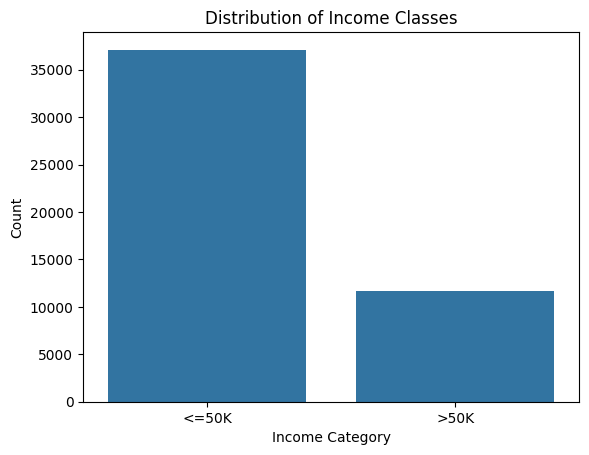

In [44]:
ax = sns.countplot(data=df, x='income')

ax.set_xlabel('Income Category')
ax.set_ylabel('Count')
ax.set_title('Distribution of Income Classes')

plt.show()

**Interpretation:**

The distribution shows that most individuals earn ≤50K, while a smaller portion earn >50K. This indicates that the dataset is imbalanced, with the majority of observations belonging to the lower income category.

##4.2 Income Distribution by Gender

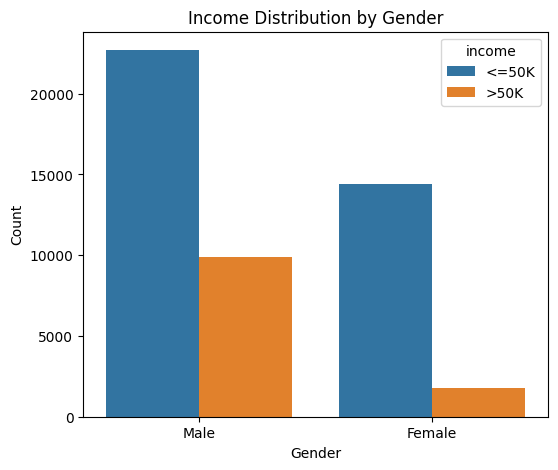

In [45]:
fig, ax = plt.subplots(figsize=(6,5))

sns.countplot(data=df, x='gender', hue='income', ax=ax)

ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_title('Income Distribution by Gender')

plt.show()

**Interpretation:**

The plot shows that males are more likely to earn >50K compared to females. Most females fall in the ≤50K income category, while a higher number of males appear in the higher income group.

##4.3 Income Distribution by Education

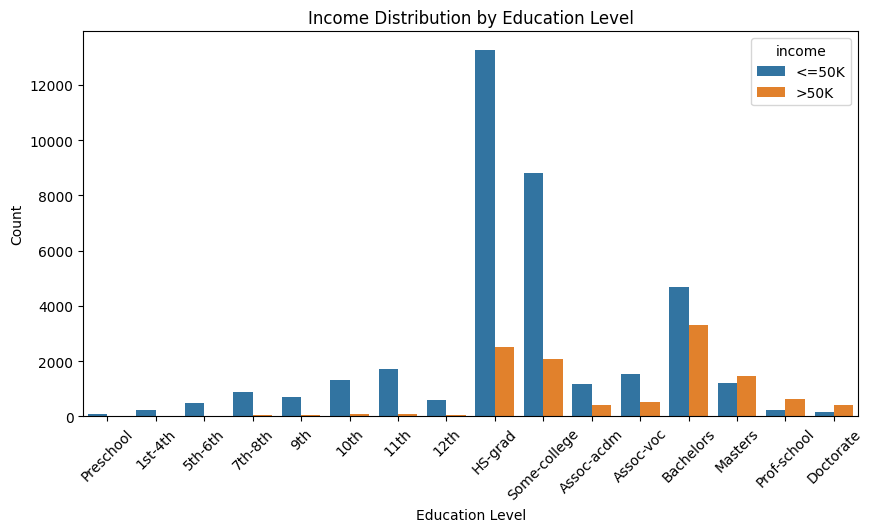

In [46]:
education_order = [
'Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th',
'HS-grad','Some-college','Assoc-acdm','Assoc-voc','Bachelors','Masters','Prof-school','Doctorate'
]

fig, ax = plt.subplots(figsize=(10,5))

sns.countplot(data=df, x='education', hue='income', order=education_order, ax=ax)

ax.set_xlabel('Education Level')
ax.set_ylabel('Count')
ax.set_title('Income Distribution by Education Level')

plt.xticks(rotation=45)
plt.show()

**Interpretation:**

The plot shows that individuals with higher education levels tend to earn higher incomes. People with Masters, Prof-school, and Doctorate degrees have a larger proportion of >50K income compared to lower education levels. In contrast, most individuals with lower education levels fall into the ≤50K income category.

##4.4 Income vs Hours Worked Per Week

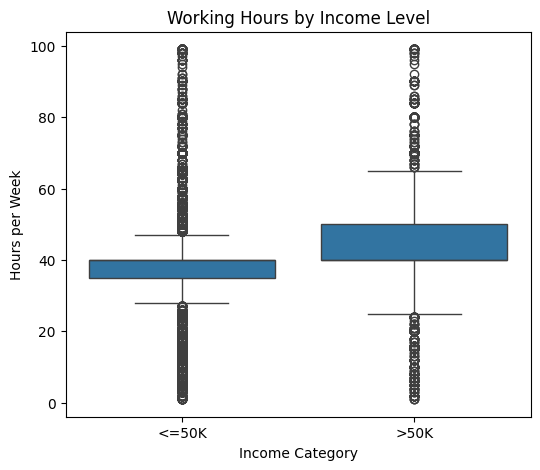

In [47]:
fig, ax = plt.subplots(figsize=(6,5))

sns.boxplot(data=df, x='income', y='hours-per-week', ax=ax)

ax.set_xlabel('Income Category')
ax.set_ylabel('Hours per Week')
ax.set_title('Working Hours by Income Level')

plt.show()

**Interpretation:**

The plot shows that individuals earning >50K tend to work more hours per week compared to those earning ≤50K. The median working hours for the higher income group is around 40–50 hours, while most individuals earning ≤50K work around 35–40 hours per week.

The plot also shows many outliers in both groups. Some individuals work very few hours (below 10 hours), while others work extremely long hours (up to around 90–100 hours per week).

##4.5 Age Distribution by Income

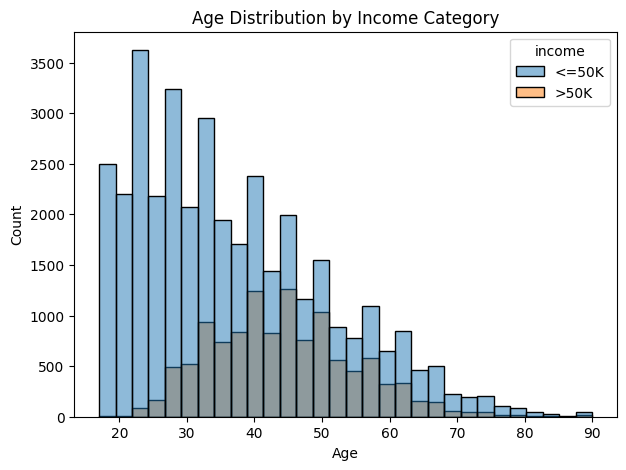

In [48]:
fig, ax = plt.subplots(figsize=(7,5))

sns.histplot(data=df, x='age', hue='income', bins=30, ax=ax)

ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age Distribution by Income Category')

plt.show()

**Interpretation:**

The histogram shows that most individuals earning ≤50K are concentrated in the younger age groups, especially between 20 and 35 years old. In contrast, individuals earning >50K appear more frequently in the middle age range (around 35–55 years old). This suggests that higher income is more common among people with greater age.

##4.6 Income by Marital Status

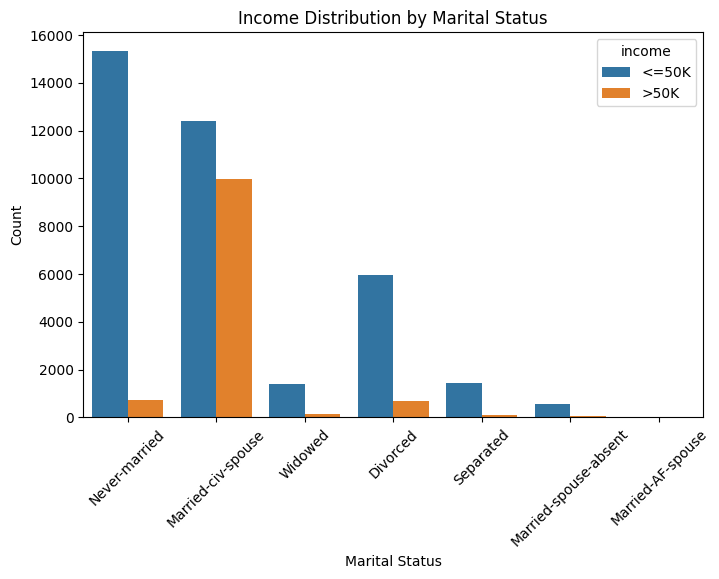

In [49]:
fig, ax = plt.subplots(figsize=(8,5))

sns.countplot(data=df, x='marital-status', hue='income', ax=ax)

ax.set_xlabel('Marital Status')
ax.set_ylabel('Count')
ax.set_title('Income Distribution by Marital Status')

plt.xticks(rotation=45)
plt.show()

**Interpretation:**

The plot shows that individuals who are Married-civ-spouse (married in a civilian marriage) have the highest number of people earning >50K, suggesting that married individuals tend to have higher incomes compared to other marital groups. In contrast, most individuals who are Never-married (never been married) fall into the ≤50K income category. Other groups such as Divorced (legally separated from a spouse) and Widowed (a person whose spouse has died) also mostly appear in the lower income category. Categories like Married-spouse-absent (married but the spouse is not living with them) and Married-AF-spouse (married to a spouse serving in the Armed Forces) have very small counts in the dataset.

##4.7 Occupations vs Income

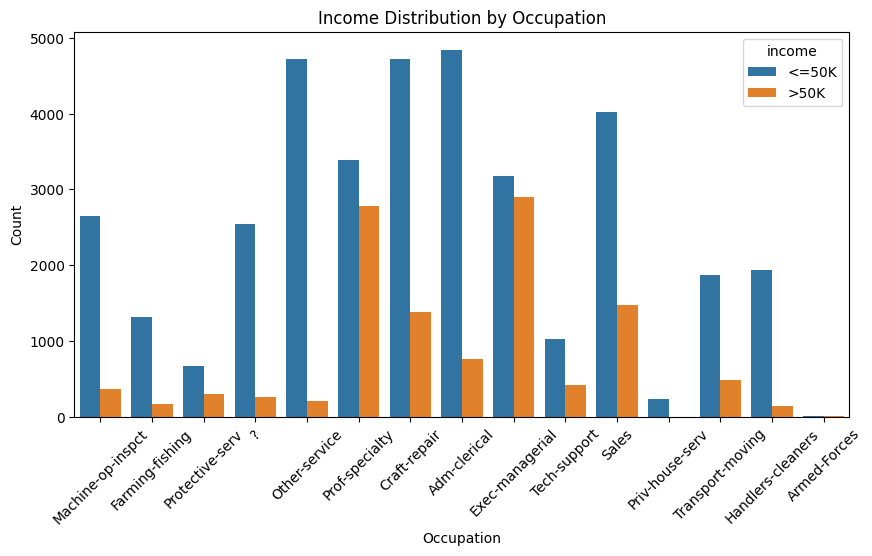

In [50]:
fig, ax = plt.subplots(figsize=(10,5))

sns.countplot(data=df, x='occupation', hue='income', ax=ax)

ax.set_xlabel('Occupation')
ax.set_ylabel('Count')
ax.set_title('Income Distribution by Occupation')

plt.xticks(rotation=45)
plt.show()

**Interpretation:**

The plot shows that income varies across different occupations. Jobs such as Exec-managerial (management positions) and Prof-specialty (professional jobs such as engineers, doctors, etc.) have a higher number of individuals earning >50K compared to other occupations. In contrast, occupations like Other-service, Machine-op-inspct, and Handlers-cleaners are mostly associated with the ≤50K income category. This suggests that professional and managerial occupations are more likely to have higher salaries than service or manual labor jobs.

#5 Modeling

##5.1 Define Target and Features and perfrom Train-Test split

In [51]:
target_col = "income"
#'education' is dropped because it duplicates the information in 'educational-num'.
#'educational-num' already represents education level numerically,
#so keeping both would introduce redundant information to the model.
drop_cols = ["education"]
y = df[target_col].copy()
X = df.drop(columns=[target_col, *drop_cols]).copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,stratify=y) #startify=y to protect class balance during splitting in train test split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print()
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print('--------------------------------')
print("y_test distribution:\n", y_test.value_counts(normalize=True))



X_train shape: (36592, 13)
X_test shape: (12198, 13)

y_train distribution:
 income
<=50K    0.760576
>50K     0.239424
Name: proportion, dtype: float64
--------------------------------
y_test distribution:
 income
<=50K    0.760616
>50K     0.239384
Name: proportion, dtype: float64


##5.2 Classification Evaluation Functions

In [52]:
#helper function: classification_metrics()
def classification_metrics(y_true,y_pred,label='',output_dict=False,figsize=(8,4),normalize='true',cmap='Blues',colorbar=False):
  header = '-' * 70
  print(header,f"Classification Metrics:{label}",header,sep='\n')
  print(classification_report(y_true,y_pred))

  fig,axes = plt.subplots(ncols=2,figsize=figsize)

  #raw counts confusion matrix
  ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=None,cmap='gist_gray',colorbar=colorbar,ax=axes[0])
  axes[0].set_title('Raw Counts')

  #normalized confusion matrix
  ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=normalize, cmap=cmap,colorbar=colorbar,ax=axes[1])
  axes[1].set_title('Normalized Confusion Matrix')
  fig.tight_layout()
  plt.show()

  if output_dict:
    return classification_report(y_true,y_pred,output_dict=True)

#____________________________________________________________________________________________

#main function : evaluate_classification()
def evaluate_classification(model,X_train,y_train,X_test,y_test,figsize=(6,4),normalize='true', output_dict=False,colorbar=False, cmap_train='Blues', cmap_test = 'Reds'):
  #training evaluation
  y_train_pred = model.predict(X_train)
  result_train = classification_metrics(y_train,y_train_pred,label='(Training Data)',output_dict=True,figsize=figsize,normalize=normalize, cmap=cmap_train,colorbar=colorbar)
  print()

  #test evaluation
  y_test_pred = model.predict(X_test)
  result_test = classification_metrics(y_test,y_test_pred,label='(Test Data)',output_dict=True,figsize=figsize,normalize=normalize, cmap=cmap_test,colorbar=colorbar)


  if output_dict:
    return {'train':result_train,'test':result_test}






##5.3 Define Feature Groups

- numeric features --> age, fnlwgt, educational-num, capital-gain, capital-loss, hours-per-week

- Nominal features --> workclass, marital-status, occupation, relationship, race, gender, native-country

- Ordinal features --> None (education was dropped because educational-num already represents the ordered education levels numerically)

In [53]:
num_cols = X_train.select_dtypes("number").columns
ohe_cols = X_train.select_dtypes("object").columns

#Print the feature groups
print(f"Numerical features are:{num_cols}")
print()
print(f"Nominal features are:{ohe_cols}")


Numerical features are:Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

Nominal features are:Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country'],
      dtype='object')


##5.4  Preprocessor for RandomForest

In [54]:
#RandomForest doesnt need Scaling, also there are no missing values but we will create an Imputer for both
num_pipe_rf = make_pipeline(SimpleImputer(strategy="median"))
num_tuple_rf = ("numeric", num_pipe_rf, num_cols)

ohe_pipe_rf = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
ohe_tuple_rf = ("categorical", ohe_pipe_rf, ohe_cols)

preprocessor_rf = ColumnTransformer([num_tuple_rf, ohe_tuple_rf],verbose_feature_names_out=False)

##5.5 Default Random Forest Classifier Model

----------------------------------------------------------------------
Classification Metrics:(Training Data)
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27831
        >50K       1.00      1.00      1.00      8761

    accuracy                           1.00     36592
   macro avg       1.00      1.00      1.00     36592
weighted avg       1.00      1.00      1.00     36592



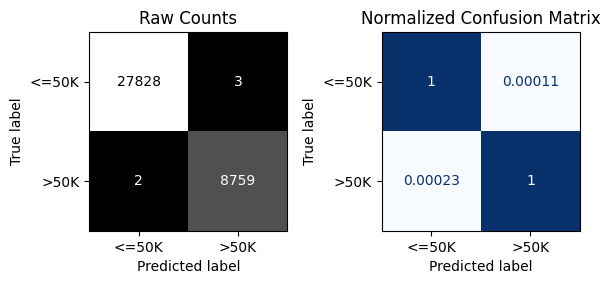


----------------------------------------------------------------------
Classification Metrics:(Test Data)
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      9278
        >50K       0.75      0.61      0.67      2920

    accuracy                           0.86     12198
   macro avg       0.81      0.77      0.79     12198
weighted avg       0.85      0.86      0.85     12198



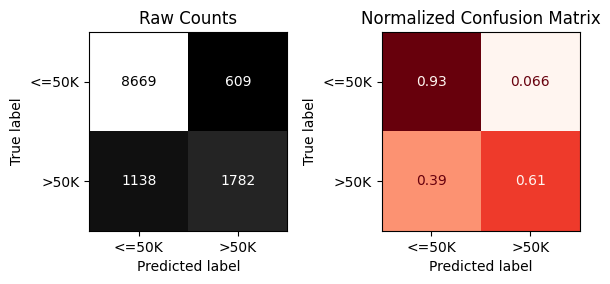

In [55]:
rf = RandomForestClassifier(random_state=42,class_weight="balanced")

rf_pipe = make_pipeline(preprocessor_rf, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

A Random Forest classifier was used as the baseline model for this project. Since the target variable is imbalanced (approximately 76% <=50K and 24% >50K), the parameter class_weight="balanced" was used so the model gives slightly more importance to the minority class during training. This helps reduce bias a little bit toward the majority class. Experiments were also conducted using SMOTE to balance the training data, but this did not significantly improve the model’s performance and slightly reduced overall accuracy and precision. Because the goal of this project is income prediction and not a highly critical task, the baseline Random Forest model with balanced class weights was considered sufficient. Additionally, the project instructions do not require extensive hyperparameter tuning, so the default model was used.

##5.6 Permutation Importance – Top 10 Features

In [56]:
r = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=5,      # number of shuffles
    random_state=42
)

#convert permutation importance to pandas
perm_importances = pd.Series( r["importances_mean"], index=X_test.columns, name="Permutation Importance")
perm_importances = perm_importances.sort_values(ascending=False)
print(perm_importances.head(10))

capital-gain       0.038039
educational-num    0.024594
marital-status     0.023758
occupation         0.017806
relationship       0.015445
age                0.014265
capital-loss       0.008854
hours-per-week     0.005116
fnlwgt             0.002902
workclass          0.002853
Name: Permutation Importance, dtype: float64


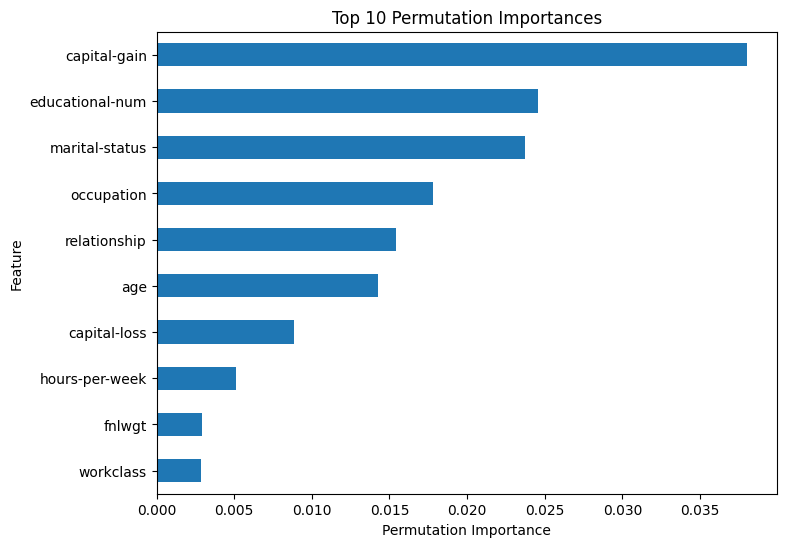

In [57]:
#Plot the top 10 important features
perm_importances.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8, 6),
    title="Top 10 Permutation Importances"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

**Interpretation:**

The permutation importance plot shows which features have the strongest impact on the model’s ability to predict whether a person earns more than 50K or less than or equal to 50K. The most important feature is capital-gain, which has the highest importance score. This indicates that profits from investments or assets play a strong role in distinguishing high-income individuals from lower-income individuals.

The second most important feature is educational-num, which represents the number of years of education. This suggests that individuals with higher education levels are more likely to earn higher incomes. Marital-status is also an important predictor, which may reflect differences in income patterns between married individuals and those who are single or divorced.

Other important features include occupation, relationship, and age, which provide information about a person's job type, family role, and career stage. These variables help the model understand factors that influence a person's income level. Capital-loss also contributes to the prediction but has a smaller effect compared to capital-gain. Finally, hours-per-week, fnlwgt, and workclass have lower importance scores, indicating they contribute less to the model’s predictions compared to the other features





**Do these features make sense based on the business case?**

Yes, these features make sense for the income prediction problem. Income is strongly influenced by factors such as education level, occupation, age, and financial investments. For example, individuals with higher education levels often qualify for better-paying jobs, and people with higher capital gains are likely to have more investments or assets, which is associated with higher income levels. Marital status and relationship roles may also influence income patterns due to differences in household structures and economic responsibilities. Overall, the most important features identified by the model align well with real-world factors that typically influence personal income, making the results reasonable and consistent with the business case of predicting income levels.


##5.7 KMeans Feature Engineering — Find the Best Number of Clusters

In this section, a clustering technique will be used as a feature engineering method.  
KMeans clustering will group similar observations in the dataset based on their numeric characteristics.  
After determining the optimal number of clusters, the cluster labels will be added as a new feature to the dataset.

This new feature may help the model capture hidden patterns in the data that were not directly visible before.  
A new model will then be trained using the original features along with the cluster feature, and its performance will be compared with the model from Part 1.

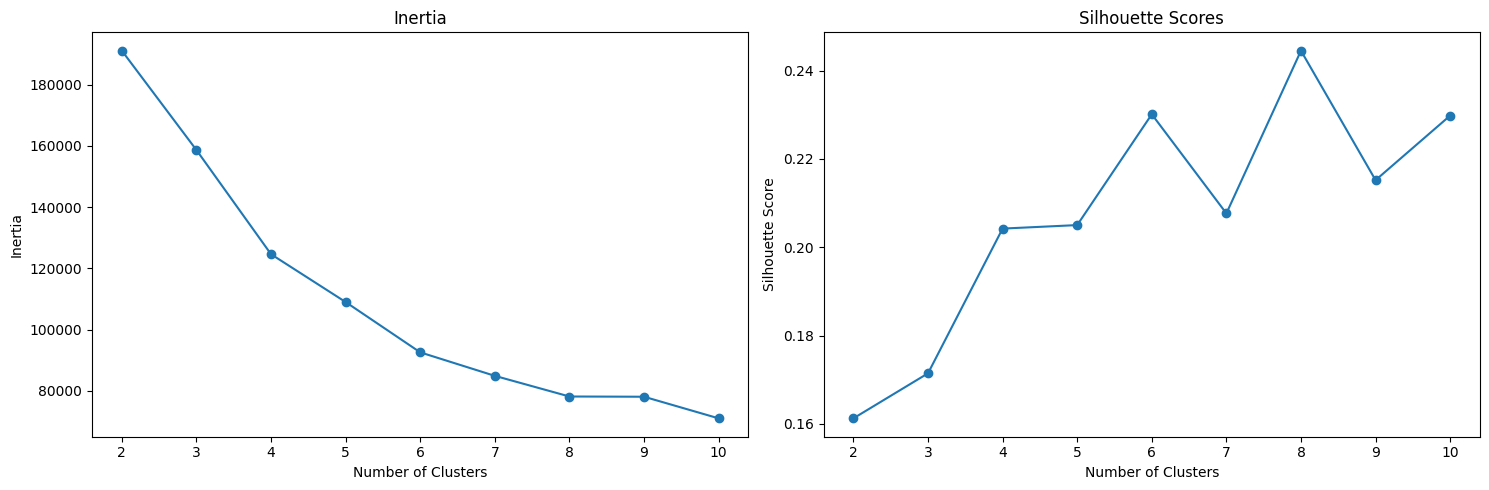

In [58]:
#copies of the original train/test data
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

#only numeric columns for clustering
kmeans_num_cols = X_train_eng.select_dtypes("number").columns

#scale numeric columns for KMeans
kmeans_scaler = StandardScaler()
X_train_kmeans_scaled = kmeans_scaler.fit_transform(X_train_eng[kmeans_num_cols])
X_test_kmeans_scaled = kmeans_scaler.transform(X_test_eng[kmeans_num_cols])

#try different values of k
ks = range(2, 11)
inertias = []
silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_train_kmeans_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_kmeans_scaled, kmeans.labels_))

#plot inerti and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Inertia')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(ks))

axes[1].plot(ks, silhouette_scores, marker='o')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(ks))

plt.tight_layout()
plt.show()

- Silhouette score peaks at 8
- Inertia also starts flattening after around 7–8
- So a reasonable choice is: best_k = 8

##5.8 Fit KMeans and Create Cluster Feature

In [62]:
best_k = 8

#fit KMeans on the training data
kmeans = KMeans(n_clusters=best_k, n_init='auto', random_state=42)
kmeans.fit(X_train_kmeans_scaled)

# create cluster labels for training and test data
X_train_eng['cluster'] = kmeans.predict(X_train_kmeans_scaled).astype('object')
X_test_eng['cluster'] = kmeans.predict(X_test_kmeans_scaled).astype('object')

X_train_eng.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,cluster
15837,42,Private,197344,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,45,United-States,5
38964,51,Private,231181,10,Never-married,Machine-op-inspct,Not-in-family,White,Male,0,0,21,United-States,5
19658,39,Private,89508,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,2
12929,43,Private,68748,9,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,United-States,5
3042,31,Private,55104,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,25,United-States,1


##5.9 Define Feature Groups Again After Adding the Cluster Feature

In [63]:
num_cols_eng = X_train_eng.select_dtypes("number").columns
ohe_cols_eng = X_train_eng.select_dtypes("object").columns

print(f"Numerical features are: {num_cols_eng}")
print()
print(f"Nominal features are: {ohe_cols_eng}")

Numerical features are: Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

Nominal features are: Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country', 'cluster'],
      dtype='object')


##5.10 Preprocessor for RandomForest with Engineered Feature

In [64]:
num_pipe_rf_eng = make_pipeline(SimpleImputer(strategy="median"))
num_tuple_rf_eng = ("numeric", num_pipe_rf_eng, num_cols_eng)

ohe_pipe_rf_eng = make_pipeline( SimpleImputer(strategy="most_frequent"), OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
ohe_tuple_rf_eng = ("categorical", ohe_pipe_rf_eng, ohe_cols_eng)

preprocessor_rf_eng = ColumnTransformer([num_tuple_rf_eng, ohe_tuple_rf_eng],verbose_feature_names_out=False)

##5.11 Random Forest Model with Engineered Feature

----------------------------------------------------------------------
Classification Metrics:(Training Data)
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27831
        >50K       1.00      1.00      1.00      8761

    accuracy                           1.00     36592
   macro avg       1.00      1.00      1.00     36592
weighted avg       1.00      1.00      1.00     36592



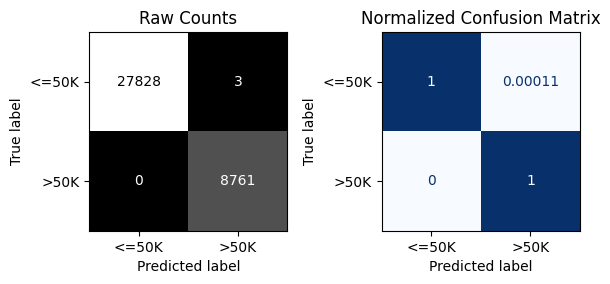


----------------------------------------------------------------------
Classification Metrics:(Test Data)
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      9278
        >50K       0.74      0.61      0.67      2920

    accuracy                           0.85     12198
   macro avg       0.81      0.77      0.79     12198
weighted avg       0.85      0.85      0.85     12198



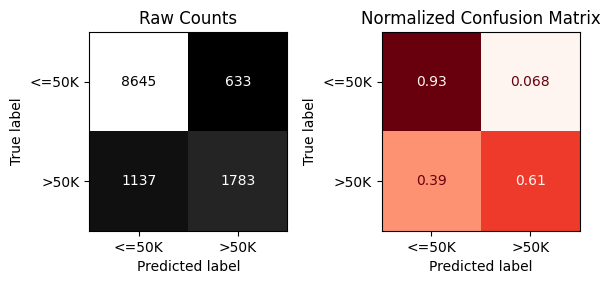

In [65]:
rf_eng = RandomForestClassifier(random_state=42, class_weight="balanced")

rf_pipe_eng = make_pipeline(preprocessor_rf_eng, rf_eng)

rf_pipe_eng.fit(X_train_eng, y_train)

evaluate_classification(rf_pipe_eng, X_train_eng, y_train, X_test_eng, y_test)

### Model Comparison

After adding the cluster feature created using KMeans clustering, a new Random Forest model was trained and evaluated.

The results show that the model performance is very similar to the baseline model from Part 1. The accuracy and recall values did not significantly change after adding the cluster feature.

This suggests that the clustering feature did not provide additional predictive information beyond the existing features. This is likely because the Random Forest model is already able to capture complex relationships in the data using the original features.

##5.12 Embedded Feature Selection with Logistic Regression

In [68]:
# numeric pipeline for feature selection
num_pipe_sel = make_pipeline(SimpleImputer(strategy="median"),StandardScaler())

#categorical pipeline for feature selection
ohe_pipe_sel = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

#preprocessor for feature selection
preprocessor_sel = ColumnTransformer([("numeric", num_pipe_sel, num_cols_eng),("categorical", ohe_pipe_sel, ohe_cols_eng) ],verbose_feature_names_out=False)

#fit and transform training data, transform test data
X_train_sel_tf = preprocessor_sel.fit_transform(X_train_eng)
X_test_sel_tf = preprocessor_sel.transform(X_test_eng)

# convert to DataFrame so we keep column names
feature_names_sel = preprocessor_sel.get_feature_names_out()

X_train_sel_tf = pd.DataFrame(
    X_train_sel_tf,
    columns=feature_names_sel,
    index=X_train_eng.index
)

X_test_sel_tf = pd.DataFrame(
    X_test_sel_tf,
    columns=feature_names_sel,
    index=X_test_eng.index
)

#logistic Regression selector
log_reg = LogisticRegression(C=1e12, max_iter=10000)

selector = SelectFromModel(log_reg)

selector.fit(X_train_sel_tf, y_train)

SelectFromModel(estimator=LogisticRegression(C=1000000000000.0, max_iter=10000))

##5.13 Select the Important Features

In [69]:
#get mask of selected features
above_threshold = selector.get_support()

#keep only selected features
X_train_final = X_train_sel_tf.loc[:, above_threshold]
X_test_final = X_test_sel_tf.loc[:, above_threshold]

print("Original transformed shape:", X_train_sel_tf.shape)
print("Selected features shape:", X_train_final.shape)

Original transformed shape: (36592, 100)
Selected features shape: (36592, 42)


##5.14 Fit Final Random Forest Model on Selected Features

----------------------------------------------------------------------
Classification Metrics:(Training Data)
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.96      0.78      0.86     27831
        >50K       0.57      0.90      0.70      8761

    accuracy                           0.81     36592
   macro avg       0.77      0.84      0.78     36592
weighted avg       0.87      0.81      0.82     36592



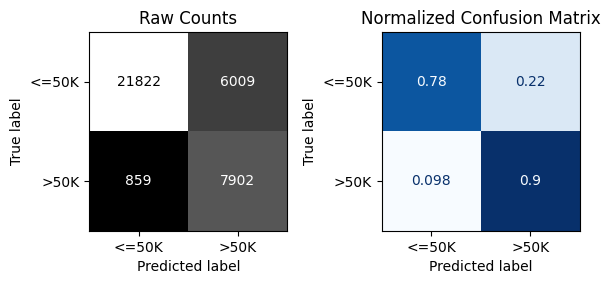


----------------------------------------------------------------------
Classification Metrics:(Test Data)
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.95      0.77      0.85      9278
        >50K       0.54      0.87      0.67      2920

    accuracy                           0.79     12198
   macro avg       0.75      0.82      0.76     12198
weighted avg       0.85      0.79      0.81     12198



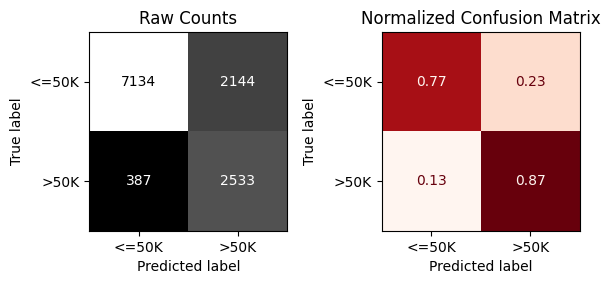

In [70]:
rf_final = RandomForestClassifier(random_state=42, class_weight="balanced")

rf_final.fit(X_train_final, y_train)

evaluate_classification(rf_final, X_train_final, y_train, X_test_final, y_test)

### Model Performance After Feature Selection

After applying embedded feature selection using Logistic Regression, the number of transformed features was reduced from 100 to 42. This helped simplify the model and remove less important features.

One important improvement is that overfitting was significantly reduced. In the previous models, the training accuracy reached 100%, which indicates that the model was likely overfitting the training data. After feature selection, the training performance became more realistic, suggesting better generalization to unseen data.

Although the overall test accuracy decreased slightly, the recall for the >50K class improved significantly from about 0.61 to 0.87. This means the final model is much better at detecting individuals with higher income.

Overall, feature selection helped reduce overfitting, simplify the model, and improve the model’s ability to detect the >50K class.

##5.15 Permutation Importance for the final model – Top 10 Features

In [71]:
# Compute permutation importance
r = permutation_importance(
    rf_final,
    X_test_final,
    y_test,
    n_repeats=5,
    random_state=42
)

#convert results to pandas Series
perm_importances = pd.Series(r["importances_mean"], index=X_test_final.columns, name="Permutation Importance")

#sort features by importance
perm_importances = perm_importances.sort_values(ascending=False)


print(perm_importances.head(10))

capital-gain                    0.033005
educational-num                 0.025201
capital-loss                    0.007542
occupation_Farming-fishing      0.003148
occupation_Handlers-cleaners    0.002640
occupation_Exec-managerial      0.002197
occupation_Other-service        0.001115
occupation_Tech-support         0.000525
native-country_Columbia         0.000475
race_Amer-Indian-Eskimo         0.000344
Name: Permutation Importance, dtype: float64


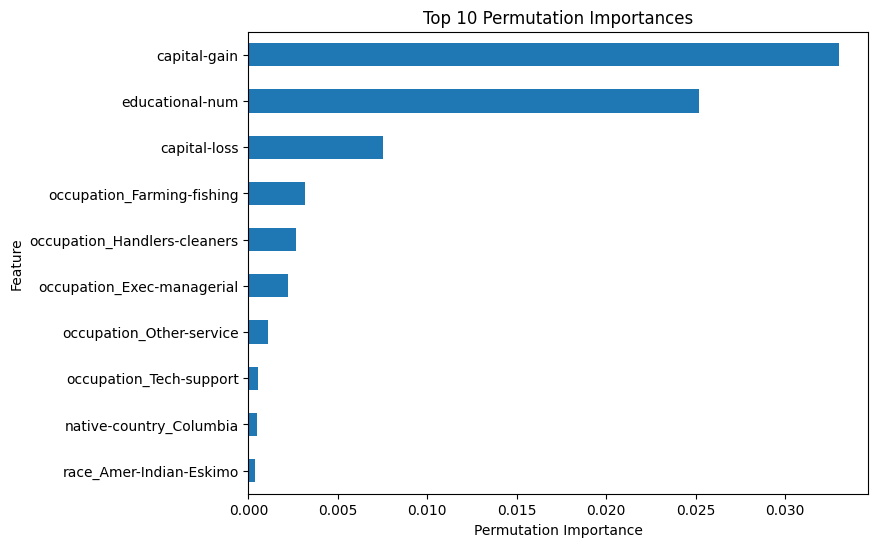

In [72]:
#plot the top 10 important features
perm_importances.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,6),
    title="Top 10 Permutation Importances"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

### Comparison with Part 1 Important Features

When comparing the top 10 features from the final model with those from Part 1, we can see that some of the most important features remained the same. Features such as **capital-gain, educational-num, and capital-loss** are still among the most important predictors of income in both models.

However, there are some differences. In Part 1, features like **marital-status, relationship, age, hours-per-week, fnlwgt, and workclass** appeared in the top 10. In the final model, several of these were replaced by more specific features created after encoding, such as **occupation_Farming-fishing, occupation_Handlers-cleaners, occupation_Exec-managerial, occupation_Other-service, occupation_Tech-support, native-country_Columbia, and race_Amer-Indian-Eskimo**.

This happened because after preprocessing and feature selection, categorical variables were transformed into multiple one-hot encoded features. As a result, the model identified specific categories within those variables as important predictors instead of the original general feature names.

Overall, some important predictors remained consistent, while new detailed features appeared in the final model due to the preprocessing and feature selection steps.

#6 Explanatory Visualizations (For Stakeholders)

##6.1 Visualization 1 - Education Level vs Income

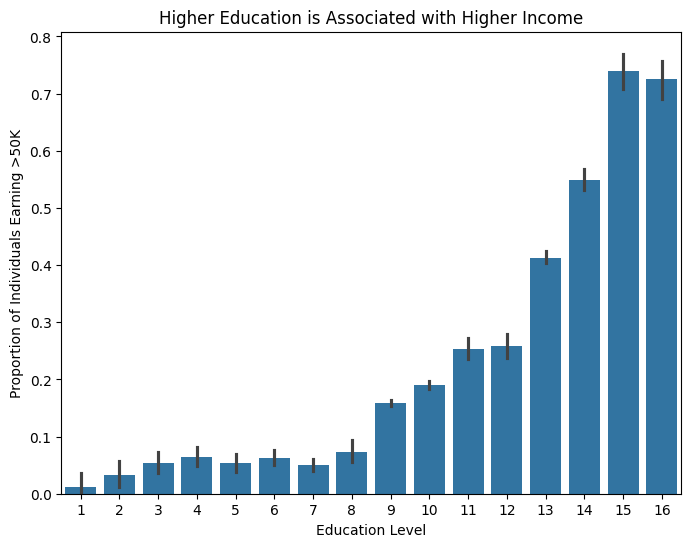

In [59]:
fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(
    data=df,
    x="educational-num",
    y=(df["income"] == ">50K"),
    ax=ax
)

ax.set_title("Higher Education is Associated with Higher Income")
ax.set_xlabel("Education Level")
ax.set_ylabel("Proportion of Individuals Earning >50K")

plt.show()

**Interpretation:**

This visualization shows how the probability of earning more than 50K changes with education level. The y-axis represents the proportion of individuals within each education group who earn more than 50K per year. The results show a clear upward trend as education increases. At lower education levels (around 1–6 years of education), only about 2%–7% of individuals earn more than 50K, meaning over 90% earn 50K or less. As education increases, the proportion gradually rises. For individuals with 9–12 years of education, roughly 16%–26% earn more than 50K. The increase becomes much stronger for higher education levels: about 41% of individuals with 13 years of education and around 55% with 14 years of education earn more than 50K. The highest proportions appear for individuals with 15–16 years of education, where approximately 73%–75% earn more than 50K. Overall, this pattern shows that higher education levels are strongly associated with higher income potential, suggesting that individuals with more education are more likely to obtain better-paying jobs and career opportunities.



##6.2 Visualization 2 - Age Groups vs Income

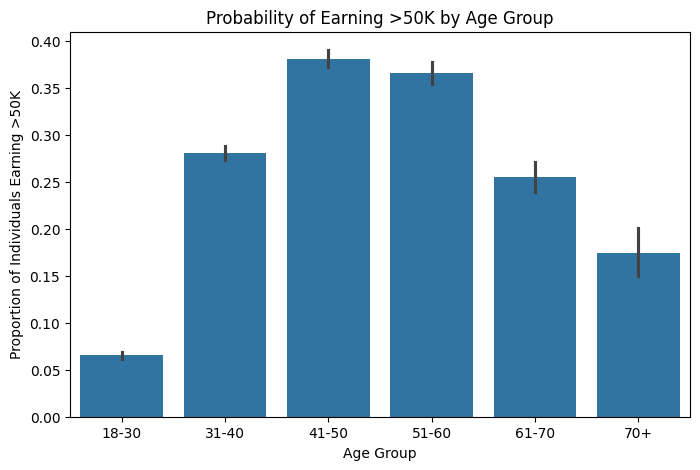

In [60]:
df["age_group"] = pd.cut(df["age"],bins=[17,30,40,50,60,70,90],labels=["18-30","31-40","41-50","51-60","61-70","70+"])

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(
    data=df,
    x="age_group",
    y=(df["income"] == ">50K"),
    ax=ax
)

ax.set_title("Probability of Earning >50K by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Proportion of Individuals Earning >50K")

plt.show()

**Interpretation:**

This visualization shows how the likelihood of earning more than 50K changes across different age groups. The results show a clear trend as age increases. Among individuals aged 18–30, only about 7% earn more than 50K, while roughly 93% earn 50K or less. In the 31–40 age group, the proportion of high-income earners increases to around 28%. The highest proportion appears in the 41–50 age group, where about 38% earn more than 50K. A similar but slightly lower proportion is observed for individuals aged 51–60, where approximately 36% earn more than 50K. After this stage, the proportion decreases, with about 26% of individuals aged 61–70 and around 17% of those aged 70+ earning more than 50K. Overall, this pattern suggests that income tends to increase as people gain work experience and advance in their careers, then gradually decline as individuals approach retirement age.



##6.3 Visualization 3 - Capital Gain vs Income

/tmp/ipykernel_916/3610763969.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Capital Gain", "Has Capital Gain"])


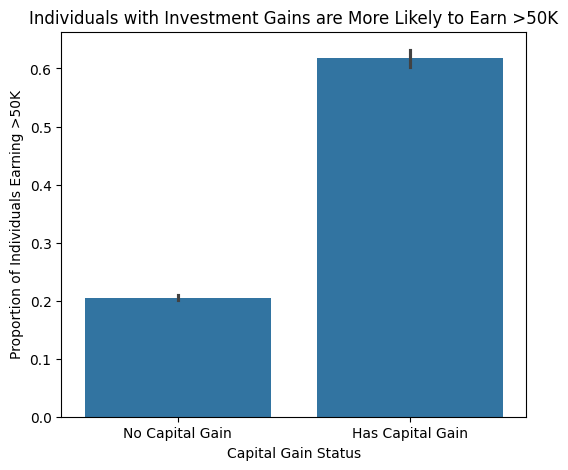

In [61]:
# Create a simple binary variable because there are many 0 values
df["has_capital_gain"] = df["capital-gain"] > 0

fig, ax = plt.subplots(figsize=(6,5))

sns.barplot(
    data=df,
    x="has_capital_gain",
    y=(df["income"] == ">50K"),
    ax=ax
)

ax.set_xticklabels(["No Capital Gain", "Has Capital Gain"])

ax.set_title("Individuals with Investment Gains are More Likely to Earn >50K")
ax.set_xlabel("Capital Gain Status")
ax.set_ylabel("Proportion of Individuals Earning >50K")

plt.show();

**Interpretation:**

This visualization compares the proportion of individuals earning more than 50K between people who have capital gains and those who do not. The results show a clear difference between the two groups. Among individuals who report capital gains, about 62% earn more than 50K, while approximately 38% earn 50K or less. In contrast, among individuals with no capital gains, only about 20% earn more than 50K, while roughly 80% earn 50K or less. This large difference suggests that individuals who generate profits from investments or assets are much more likely to belong to the higher income group. This indicates that investment income is strongly associated with higher overall earnings.



